# Crisis Connect — Phase 4: Fusion Layer + Severity Estimator
**CSC-233 Artificial Intelligence Lab | Spring 2026**
**Component owner: Syed Hudair Shah Bukhari**

### What this notebook does:
1. Loads ResNet-50 CNN model (Phase 2) and MLP text classifier (Phase 3b)
2. Runs both models on the same input
3. Combines probabilities: CNN 70% + MLP 30% = final prediction
4. Maps final prediction to severity level: Low / Medium / High
5. Tests the full pipeline end to end
6. Saves the fusion logic as a reusable module for Phase 5

**Requires these files on Drive:**
- crisis connect_model/resnet50_crisis_connect.pth
- crisis connect_phase3b/mlp_classifier.pkl
- crisis connect_phase3a/tfidf_vectorizer.pkl
- crisis connect_phase3a/label_encoder.pkl

## Cell 1 — Install and import

In [2]:
!pip install torch torchvision scikit-learn Pillow -q

import os
import re
import numpy as np
import joblib
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('All packages imported.')

Device: cuda
All packages imported.


## Cell 2 — Mount Drive and set paths

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

CNN_MODEL_PATH  = '/content/drive/MyDrive/crisis connect_model/resnet50_crisis_connect.pth'
MLP_MODEL_PATH  = '/content/drive/MyDrive/crisis connect_phase3b/mlp_classifier.pkl'
VECTORIZER_PATH = '/content/drive/MyDrive/crisis connect_phase3a/tfidf_vectorizer.pkl'
ENCODER_PATH    = '/content/drive/MyDrive/crisis connect_phase3a/label_encoder.pkl'
OUTPUT_DIR      = '/content/drive/MyDrive/crisis connect_phase4'
SPLIT_DIR       = '/content/drive/MyDrive/crisis connect_split'

CLASSES = ['earthquake', 'flood', 'fire', 'traffic_incident']

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify all required files exist
required = [
    CNN_MODEL_PATH, MLP_MODEL_PATH,
    VECTORIZER_PATH, ENCODER_PATH
]
print('Checking required files:')
all_ok = True
for path in required:
    exists = os.path.exists(path)
    status = 'FOUND' if exists else 'NOT FOUND'
    if not exists:
        all_ok = False
    print(f'  {status}  {os.path.basename(path)}')
print()
if all_ok:
    print('All files found. Ready to proceed.')
else:
    print('Fix missing files before continuing.')

Mounted at /content/drive
Checking required files:
  FOUND  resnet50_crisis_connect.pth
  FOUND  mlp_classifier.pkl
  FOUND  tfidf_vectorizer.pkl
  FOUND  label_encoder.pkl

All files found. Ready to proceed.


## Cell 3 — Load CNN model (ResNet-50 from Phase 2)

In [4]:
from torchvision import models
import torch
import torch.nn as nn

NUM_CLASSES = 4

# Rebuild the same architecture used in Phase 2
cnn_model = models.resnet50(pretrained=False)
in_features = cnn_model.fc.in_features
cnn_model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, NUM_CLASSES)
)

# Load saved weights
checkpoint = torch.load(CNN_MODEL_PATH, map_location=device)
cnn_model.load_state_dict(checkpoint['model_state_dict'])
cnn_model = cnn_model.to(device)
cnn_model.eval()

# CNN class order (from Phase 2 training)
cnn_class_to_idx = checkpoint['class_to_idx']
cnn_idx_to_class = {v: k for k, v in cnn_class_to_idx.items()}

print('ResNet-50 CNN model loaded.')
print(f'Test accuracy from Phase 2 : {checkpoint["test_accuracy"]*100:.2f}%')
print(f'CNN class order : {cnn_idx_to_class}')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet-50 CNN model loaded.
Test accuracy from Phase 2 : 91.03%
CNN class order : {0: 'earthquake', 1: 'fire', 2: 'flood', 3: 'traffic_incident'}


## Cell 4 — Load MLP model and TF-IDF tools (Phase 3a + 3b)

In [6]:
import joblib

mlp_model  = joblib.load(MLP_MODEL_PATH)
vectorizer = joblib.load(VECTORIZER_PATH)
le         = joblib.load(ENCODER_PATH)

print('MLP classifier loaded.')
print('TF-IDF vectorizer loaded.')
print('Label encoder loaded.')
print()
print(f'MLP classes  : {le.classes_}')
print(f'TF-IDF features : {len(vectorizer.get_feature_names_out())}')

MLP classifier loaded.
TF-IDF vectorizer loaded.
Label encoder loaded.

MLP classes  : ['earthquake' 'fire' 'flood' 'traffic_incident']
TF-IDF features : 1208


## Cell 5 — Define image preprocessing and text cleaning

In [7]:
from torchvision import transforms
from nltk.corpus import stopwords
import nltk
import re
nltk.download('stopwords', quiet=True)

# Image transform (same as Phase 2 eval transform)
img_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Text cleaning (same as Phase 3a)
stop_words = set(stopwords.words('english'))
KEEP_WORDS = {'no', 'not', 'very', 'too', 'above', 'below', 'near', 'under', 'over'}
stop_words = stop_words - KEEP_WORDS

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [t for t in text.split() if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print('Image transform defined.')
print('Text cleaning function defined.')

Image transform defined.
Text cleaning function defined.


## Cell 6 — Fusion function (CNN 70% + MLP 30%)

In [8]:
import numpy as np
import torch

# Fusion weights from proposal
CNN_WEIGHT = 0.70
MLP_WEIGHT = 0.30

# Severity rules
# Based on confidence score of the final fused prediction
def get_severity(confidence, predicted_class):
    """
    Maps confidence score + class to severity level.
    High confidence + dangerous class = High severity
    """
    HIGH_RISK_CLASSES = ['earthquake', 'flood']
    if confidence >= 0.75:
        if predicted_class in HIGH_RISK_CLASSES:
            return 'High'
        else:
            return 'Medium'
    elif confidence >= 0.50:
        return 'Medium'
    else:
        return 'Low'

def fuse_predict(image_path, text_description):
    """
    Full fusion pipeline:
    1. Run CNN on image -> class probabilities
    2. Run MLP on text  -> class probabilities
    3. Weighted average: CNN*0.70 + MLP*0.30
    4. Final class = argmax of fused probabilities
    5. Severity = based on confidence + class

    Returns: predicted_class, confidence, severity, cnn_probs, mlp_probs, fused_probs
    """

    # ── CNN prediction ──────────────────────────────────────
    img = Image.open(image_path).convert('RGB')
    tensor = img_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        cnn_output = cnn_model(tensor)
        cnn_probs  = torch.softmax(cnn_output, dim=1)[0].cpu().numpy()

    # CNN outputs in cnn_idx_to_class order
    # Reorder to match CLASSES order
    cnn_probs_ordered = np.zeros(len(CLASSES))
    for idx, cls in cnn_idx_to_class.items():
        if cls in CLASSES:
            target_idx = CLASSES.index(cls)
            cnn_probs_ordered[target_idx] = cnn_probs[idx]

    # ── MLP prediction ──────────────────────────────────────
    cleaned = clean_text(text_description)
    vec     = vectorizer.transform([cleaned])
    mlp_probs_raw = mlp_model.predict_proba(vec)[0]

    # MLP outputs in le.classes_ order
    # Reorder to match CLASSES order
    mlp_probs_ordered = np.zeros(len(CLASSES))
    for i, cls in enumerate(le.classes_):
        if cls in CLASSES:
            target_idx = CLASSES.index(cls)
            mlp_probs_ordered[target_idx] = mlp_probs_raw[i]

    # ── Fusion ──────────────────────────────────────────────
    fused_probs = (CNN_WEIGHT * cnn_probs_ordered) + (MLP_WEIGHT * mlp_probs_ordered)

    # Final prediction
    pred_idx        = np.argmax(fused_probs)
    predicted_class = CLASSES[pred_idx]
    confidence      = fused_probs[pred_idx]

    # Severity
    severity = get_severity(confidence, predicted_class)

    return {
        'predicted_class':  predicted_class,
        'confidence':       float(confidence),
        'severity':         severity,
        'cnn_probs':        cnn_probs_ordered,
        'mlp_probs':        mlp_probs_ordered,
        'fused_probs':      fused_probs,
        'cnn_top':          CLASSES[np.argmax(cnn_probs_ordered)],
        'mlp_top':          CLASSES[np.argmax(mlp_probs_ordered)]
    }

print('Fusion function defined.')
print(f'Weights: CNN={CNN_WEIGHT*100:.0f}%  MLP={MLP_WEIGHT*100:.0f}%')

Fusion function defined.
Weights: CNN=70%  MLP=30%


## Cell 7 — Test fusion on real images from split dataset

Running fusion on test images...

Class    : earthquake
Text     : "Strong shaking felt walls cracked people running outside bui"
CNN pred : earthquake  |  MLP pred: earthquake
FUSED    : earthquake  (confidence: 0.9607)
Severity : High
Correct  : True

Class    : flood
Text     : "Water rising fast on main road bridge submerged houses flood"
CNN pred : flood  |  MLP pred: flood
FUSED    : flood  (confidence: 0.8216)
Severity : High
Correct  : True

Class    : fire
Text     : "Large fire in market shops burning black smoke visible from "
CNN pred : earthquake  |  MLP pred: fire
FUSED    : earthquake  (confidence: 0.5893)
Severity : Medium
Correct  : False

Class    : traffic_incident
Text     : "Truck overturned on highway blocking all lanes accident"
CNN pred : traffic_incident  |  MLP pred: traffic_incident
FUSED    : traffic_incident  (confidence: 0.9657)
Severity : Medium
Correct  : True



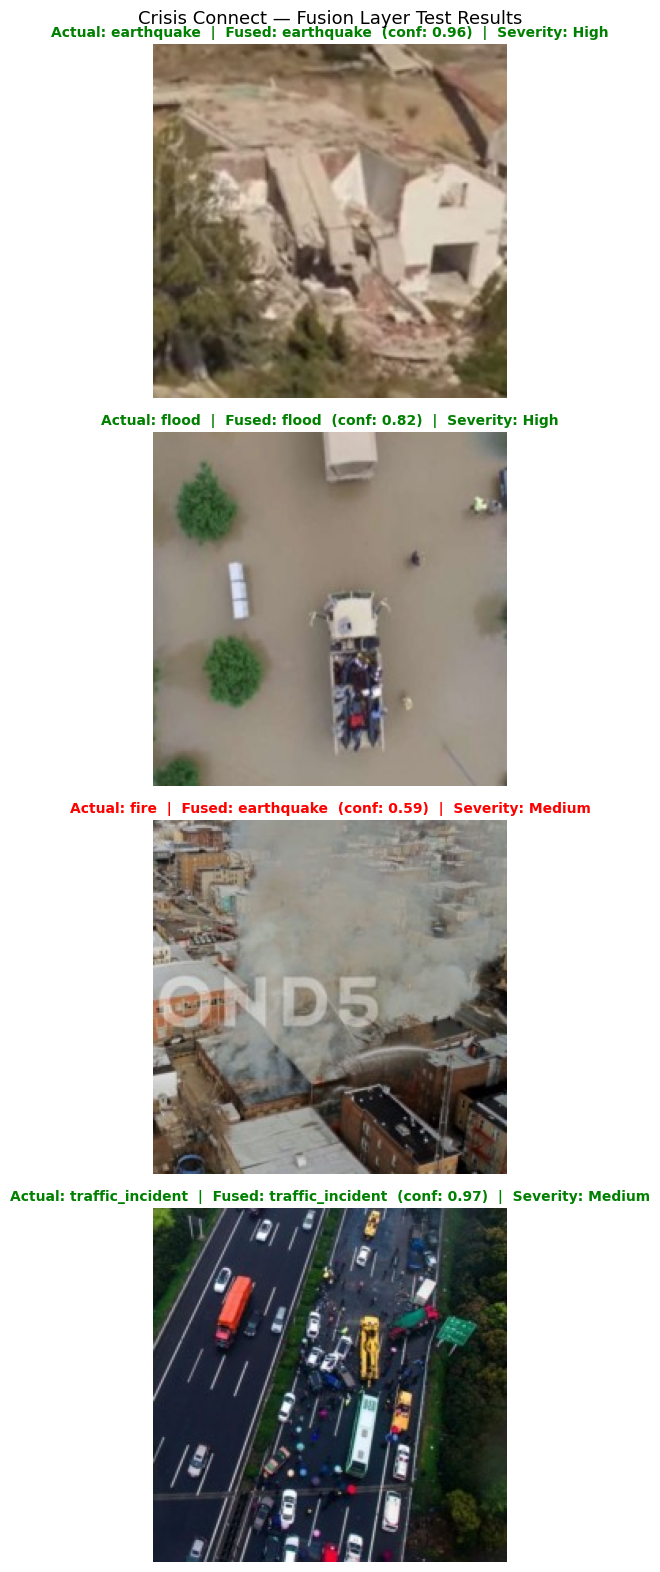

Test results saved: /content/drive/MyDrive/crisis connect_phase4/fusion_test_results.png


In [9]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches

random.seed(42)

# Sample text descriptions for each class
SAMPLE_TEXTS = {
    'earthquake': 'Strong shaking felt walls cracked people running outside building',
    'flood':      'Water rising fast on main road bridge submerged houses flooded',
    'fire':       'Large fire in market shops burning black smoke visible from far',
    'traffic_incident': 'Truck overturned on highway blocking all lanes accident'
}

fig, axes = plt.subplots(len(CLASSES), 1, figsize=(10, len(CLASSES) * 4))
fig.suptitle('Crisis Connect — Fusion Layer Test Results', fontsize=13)

print('Running fusion on test images...')
print()

for row, cls in enumerate(CLASSES):
    # Pick random test image
    folder = os.path.join(SPLIT_DIR, 'test', cls)
    files  = [f for f in os.listdir(folder) if f.endswith('.jpg')]
    img_path = os.path.join(folder, random.choice(files))
    text     = SAMPLE_TEXTS[cls]

    # Run fusion
    result = fuse_predict(img_path, text)

    correct = result['predicted_class'] == cls
    color   = 'green' if correct else 'red'

    # Print result
    print(f'Class    : {cls}')
    print(f'Text     : "{text[:60]}"')
    print(f'CNN pred : {result["cnn_top"]}  |  MLP pred: {result["mlp_top"]}')
    print(f'FUSED    : {result["predicted_class"]}  (confidence: {result["confidence"]:.4f})')
    print(f'Severity : {result["severity"]}')
    print(f'Correct  : {correct}')
    print()

    # Plot
    ax = axes[row]
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        f'Actual: {cls}  |  Fused: {result["predicted_class"]}  '
        f'(conf: {result["confidence"]:.2f})  |  Severity: {result["severity"]}',
        color=color, fontsize=10, fontweight='bold'
    )

plt.tight_layout()
test_path = os.path.join(OUTPUT_DIR, 'fusion_test_results.png')
plt.savefig(test_path, dpi=80, bbox_inches='tight')
plt.show()
print(f'Test results saved: {test_path}')

## Cell 8 — Evaluate fusion on full test set

In [10]:
import os
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

SAMPLE_TEXTS = {
    'earthquake': 'Strong shaking felt walls cracked people running outside building',
    'flood':      'Water rising fast on main road bridge submerged houses flooded',
    'fire':       'Large fire in market shops burning black smoke visible from far',
    'traffic_incident': 'Truck overturned on highway blocking all lanes accident'
}

all_preds  = []
all_labels = []

print('Evaluating fusion on full test set...')
print()

for cls in CLASSES:
    folder = os.path.join(SPLIT_DIR, 'test', cls)
    files  = [f for f in os.listdir(folder) if f.endswith('.jpg')]
    text   = SAMPLE_TEXTS[cls]
    correct = 0

    for fname in files:
        img_path = os.path.join(folder, fname)
        try:
            result = fuse_predict(img_path, text)
            all_preds.append(result['predicted_class'])
            all_labels.append(cls)
            if result['predicted_class'] == cls:
                correct += 1
        except Exception as e:
            pass

    print(f'  {cls:<22} {correct}/{len(files)} correct  ({correct/len(files)*100:.1f}%)')

overall = accuracy_score(all_labels, all_preds)
print()
print(f'Overall Fusion Accuracy: {overall:.4f}  ({overall*100:.2f}%)')
print()
print('Fusion Classification Report:')
print('=' * 60)
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

Evaluating fusion on full test set...

  earthquake             114/122 correct  (93.4%)
  flood                  124/130 correct  (95.4%)
  fire                   115/120 correct  (95.8%)
  traffic_incident       71/74 correct  (95.9%)

Overall Fusion Accuracy: 0.9507  (95.07%)

Fusion Classification Report:
                  precision    recall  f1-score   support

      earthquake     0.9500    0.9344    0.9421       122
           flood     1.0000    0.9583    0.9787       120
            fire     0.9612    0.9538    0.9575       130
traffic_incident     0.8659    0.9595    0.9103        74

        accuracy                         0.9507       446
       macro avg     0.9443    0.9515    0.9472       446
    weighted avg     0.9528    0.9507    0.9512       446



## Cell 9 — Save fusion module for Phase 5

In [11]:
# Save the fusion predict function and all config as a Python module
# Phase 5 (Streamlit) will import this directly

fusion_code = '''
import os, re, numpy as np, torch, joblib
from torchvision import models, transforms
from torch import nn
from PIL import Image
from nltk.corpus import stopwords

CLASSES     = ["earthquake", "flood", "fire", "traffic_incident"]
CNN_WEIGHT  = 0.70
MLP_WEIGHT  = 0.30
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_models(cnn_path, mlp_path, vec_path, enc_path):
    # CNN
    cnn = models.resnet50(pretrained=False)
    cnn.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(cnn.fc.in_features, 4))
    ckpt = torch.load(cnn_path, map_location=device)
    cnn.load_state_dict(ckpt["model_state_dict"])
    cnn = cnn.to(device)
    cnn.eval()
    cnn_class_to_idx = ckpt["class_to_idx"]
    cnn_idx_to_class = {v: k for k, v in cnn_class_to_idx.items()}
    # MLP
    mlp = joblib.load(mlp_path)
    vec = joblib.load(vec_path)
    le  = joblib.load(enc_path)
    return cnn, cnn_idx_to_class, mlp, vec, le

img_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def clean_text(text):
    import nltk
    nltk.download("stopwords", quiet=True)
    sw = set(stopwords.words("english")) - {"no","not","very","too","above","below","near","under","over"}
    text = re.sub(r"[^a-z\\s]", " ", str(text).lower())
    return " ".join([t for t in text.split() if t not in sw and len(t) > 2])

def get_severity(confidence, predicted_class):
    HIGH_RISK = ["earthquake", "flood"]
    if confidence >= 0.75:
        return "High" if predicted_class in HIGH_RISK else "Medium"
    elif confidence >= 0.50:
        return "Medium"
    return "Low"

def fuse_predict(image, text, cnn, cnn_idx_to_class, mlp, vec, le):
    # CNN
    if isinstance(image, str):
        img = Image.open(image).convert("RGB")
    else:
        img = Image.fromarray(image).convert("RGB")
    tensor = img_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        cnn_probs_raw = torch.softmax(cnn(tensor), dim=1)[0].cpu().numpy()
    cnn_probs = np.zeros(len(CLASSES))
    for idx, cls in cnn_idx_to_class.items():
        if cls in CLASSES:
            cnn_probs[CLASSES.index(cls)] = cnn_probs_raw[idx]
    # MLP
    mlp_probs_raw = mlp.predict_proba(vec.transform([clean_text(text)]))[0]
    mlp_probs = np.zeros(len(CLASSES))
    for i, cls in enumerate(le.classes_):
        if cls in CLASSES:
            mlp_probs[CLASSES.index(cls)] = mlp_probs_raw[i]
    # Fuse
    fused      = CNN_WEIGHT * cnn_probs + MLP_WEIGHT * mlp_probs
    pred_idx   = int(np.argmax(fused))
    pred_class = CLASSES[pred_idx]
    confidence = float(fused[pred_idx])
    return {
        "predicted_class": pred_class,
        "confidence":      confidence,
        "severity":        get_severity(confidence, pred_class),
        "cnn_probs":       cnn_probs.tolist(),
        "mlp_probs":       mlp_probs.tolist(),
        "fused_probs":     fused.tolist()
    }
'''

module_path = os.path.join(OUTPUT_DIR, 'fusion.py')
with open(module_path, 'w') as f:
    f.write(fusion_code)

print(f'Fusion module saved: {module_path}')
print()
print('Phase 5 (Streamlit) will import this module directly.')

Fusion module saved: /content/drive/MyDrive/crisis connect_phase4/fusion.py

Phase 5 (Streamlit) will import this module directly.


## Cell 10 — Summary

In [12]:
import os

print('=' * 55)
print('  Phase 4 Complete — Fusion Layer + Severity Estimator')
print('=' * 55)
print()
print(f'CNN weight  : {CNN_WEIGHT*100:.0f}%')
print(f'MLP weight  : {MLP_WEIGHT*100:.0f}%')
print()
print('Severity mapping:')
print('  confidence >= 0.75 + earthquake/flood  ->  High')
print('  confidence >= 0.75 + fire/traffic       ->  Medium')
print('  confidence >= 0.50                      ->  Medium')
print('  confidence < 0.50                       ->  Low')
print()
print('Files saved to: crisis connect_phase4/')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
    print(f'  {f:<35} {size:.1f} KB')
print()
print('Hand off to Maleeha + Abdulraheem (Phase 5 Streamlit):')
print('  crisis connect_phase4/fusion.py')
print('  crisis connect_model/resnet50_crisis_connect.pth')
print('  crisis connect_phase3b/mlp_classifier.pkl')
print('  crisis connect_phase3a/tfidf_vectorizer.pkl')
print('  crisis connect_phase3a/label_encoder.pkl')

  Phase 4 Complete — Fusion Layer + Severity Estimator

CNN weight  : 70%
MLP weight  : 30%

Severity mapping:
  confidence >= 0.75 + earthquake/flood  ->  High
  confidence >= 0.75 + fire/traffic       ->  Medium
  confidence >= 0.50                      ->  Medium
  confidence < 0.50                       ->  Low

Files saved to: crisis connect_phase4/
  fusion.py                           2.9 KB
  fusion_test_results.png             502.3 KB

Hand off to Maleeha + Abdulraheem (Phase 5 Streamlit):
  crisis connect_phase4/fusion.py
  crisis connect_model/resnet50_crisis_connect.pth
  crisis connect_phase3b/mlp_classifier.pkl
  crisis connect_phase3a/tfidf_vectorizer.pkl
  crisis connect_phase3a/label_encoder.pkl


In [13]:
import os
path = '/content/drive/MyDrive/crisis connect_model/resnet50_crisis_connect.pth'
size = os.path.getsize(path) / 1024 / 1024
print(f'Model size: {size:.1f} MB')

Model size: 90.0 MB
